# Exploratory Data Analysis: San Francisco Traffic Stops

In [1]:
# import necessary libraries and functions
from bias_analysis_functions import *
from bias_dp_functions import *
import pandas as pd
import geopandas as gpd
import numpy as np
import zipfile
from shapely.ops import unary_union

### Hardcoded Values
- Edit hardcoded values here if changing the pipeline to include new features or data.
- If reproducing same results, leave the following chunk as is.

In [3]:
### Values Specific to Analysis

# column names
date_col = "date"
race_col = "subject_race"
time_col = "time"
epc_col = "epc_class"

# Vision Zero cutoff date
cutoff_date = "2014-03-18"
counties_of_interest = ["San Francisco"]

# races to include in period analysis
races = ["hispanic", "black"]

# output directory
output_dir = "../output"

# SF demographic breakdown from 2010 Census
population = {
    "white": 337451,
    "black": 46751,
    "asian/pacific islander": 265700 + 3128,
    "hispanic": 121774
}

# display labels for race categories
race_map = {
    "white": "White",
    "black": "Black",
    "asian/pacific islander": "Asian/Pacific Islander",
    "hispanic": "Hispanic"
}

### Load Data

In [4]:
stop_path = r"../data/clean_data/stops_clean.csv.zip"
epc_path = r"../data/raw_data/communities_of_concern.geojson"
county_path = r"../data/raw_data/Bay_Area_County_Polygons.geojson"

stops_df = load_data(stop_path)
epc_gdf = load_data(epc_path)
county_gdf = load_data(county_path)

stops_df = add_year(stops_df, date_col)

stops_clean.csv.zip file unzipped.
stops_clean.csv.zip converted to dataframe.
communities_of_concern.geojson converted to dataframe.
Bay_Area_County_Polygons.geojson converted to dataframe.
year column added


Prepare data for plotting format

### Communities of Concern Map
- Plot which census tracts have been identified as communities of concern by EPC class.

epc polygons prepared
plot saved to ../output/epc_map.png


/Users/berkeleyho/Documents/College 22-26 Info/Spring '26/sds357-project-sp26-con-founders/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 5 in image.
/Users/berkeleyho/Documents/College 22-26 Info/Spring '26/sds357-project-sp26-con-founders/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../output/epc_map.png


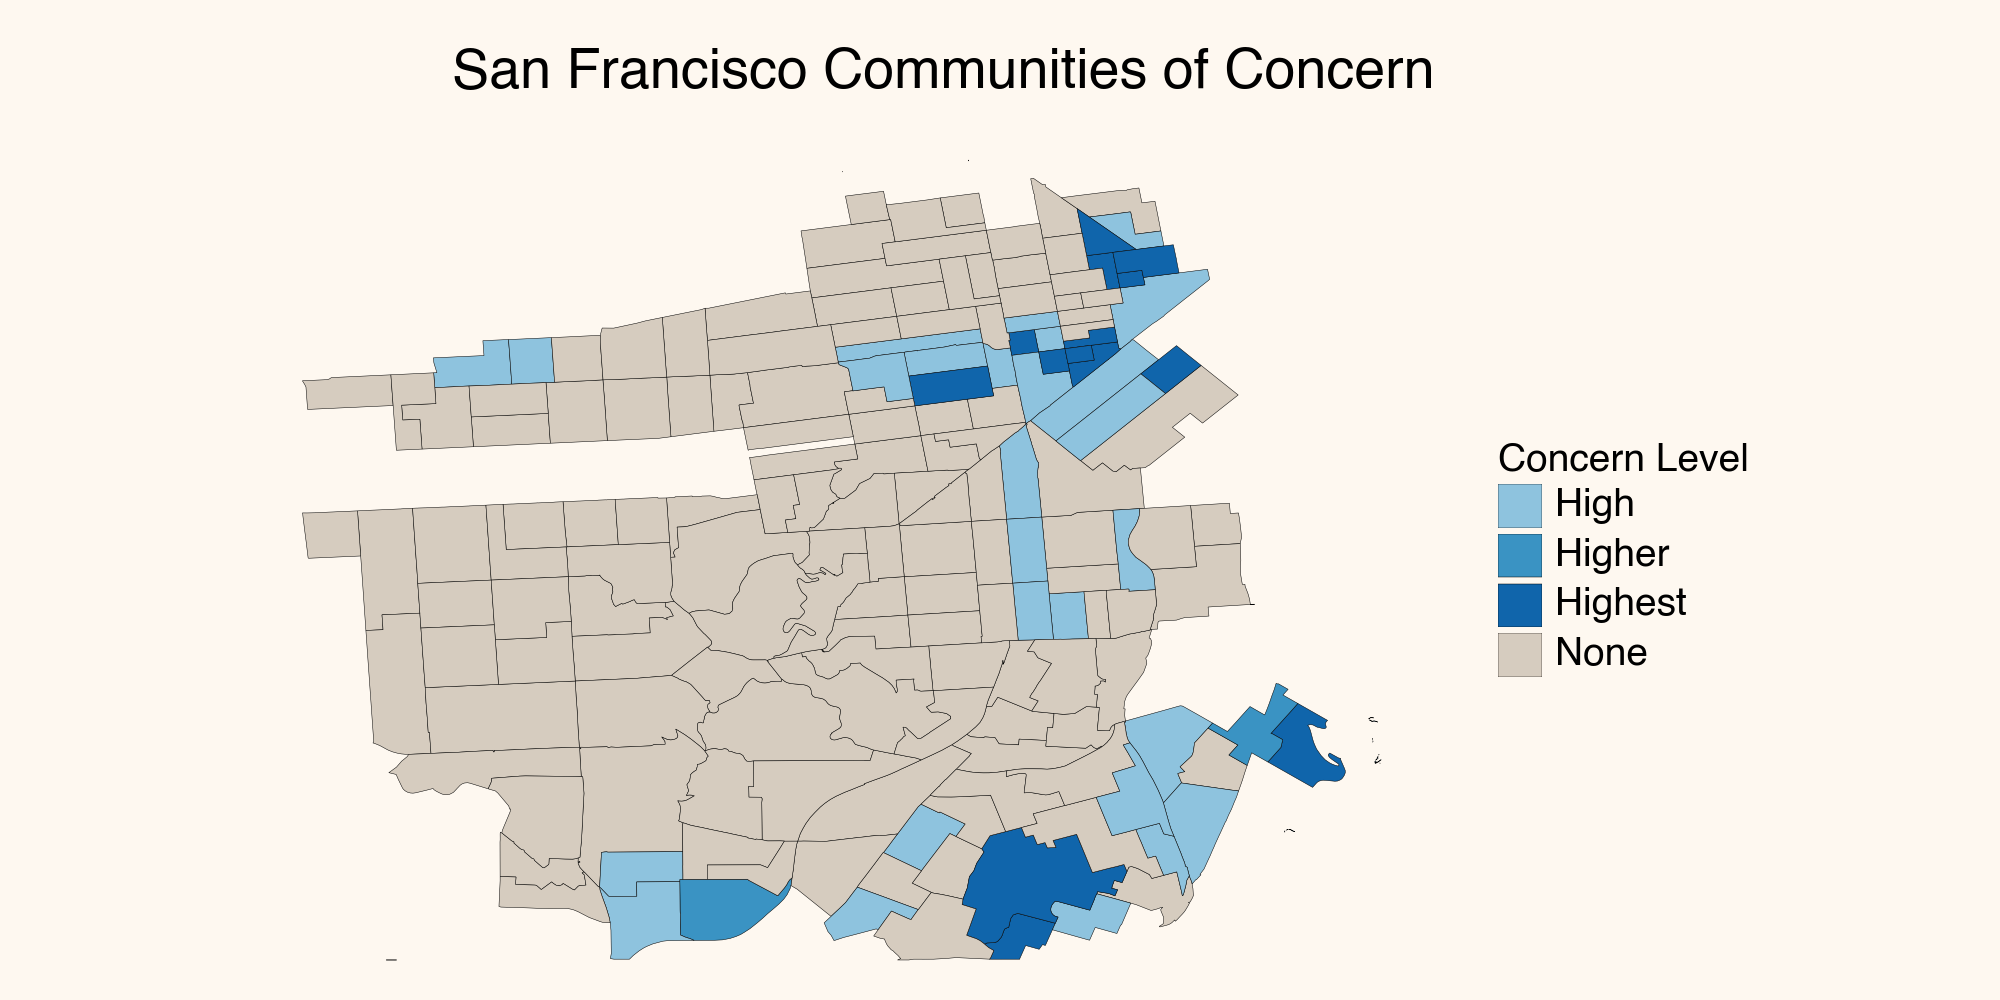

In [5]:
epc_polygon_df = prep_epc_polygons(epc_gdf, county_gdf, counties_of_interest)

epc_plot = plot_epc_map(epc_polygon_df)
save_plot(epc_plot, "epc_map.png", output_dir=output_dir, width=10, height=5)
epc_plot

### Stop Density Map by Race and Period
- Plot the geographic concentration of stops for Black and Hispanic drivers in the two years before and after Vision Zero.

race labels remapped
stops period data prepared
contours computed


/Users/berkeleyho/Documents/College 22-26 Info/Spring '26/sds357-project-sp26-con-founders/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 16 x 10 in image.
/Users/berkeleyho/Documents/College 22-26 Info/Spring '26/sds357-project-sp26-con-founders/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../output/density_map.png


plot saved to ../output/density_map.png


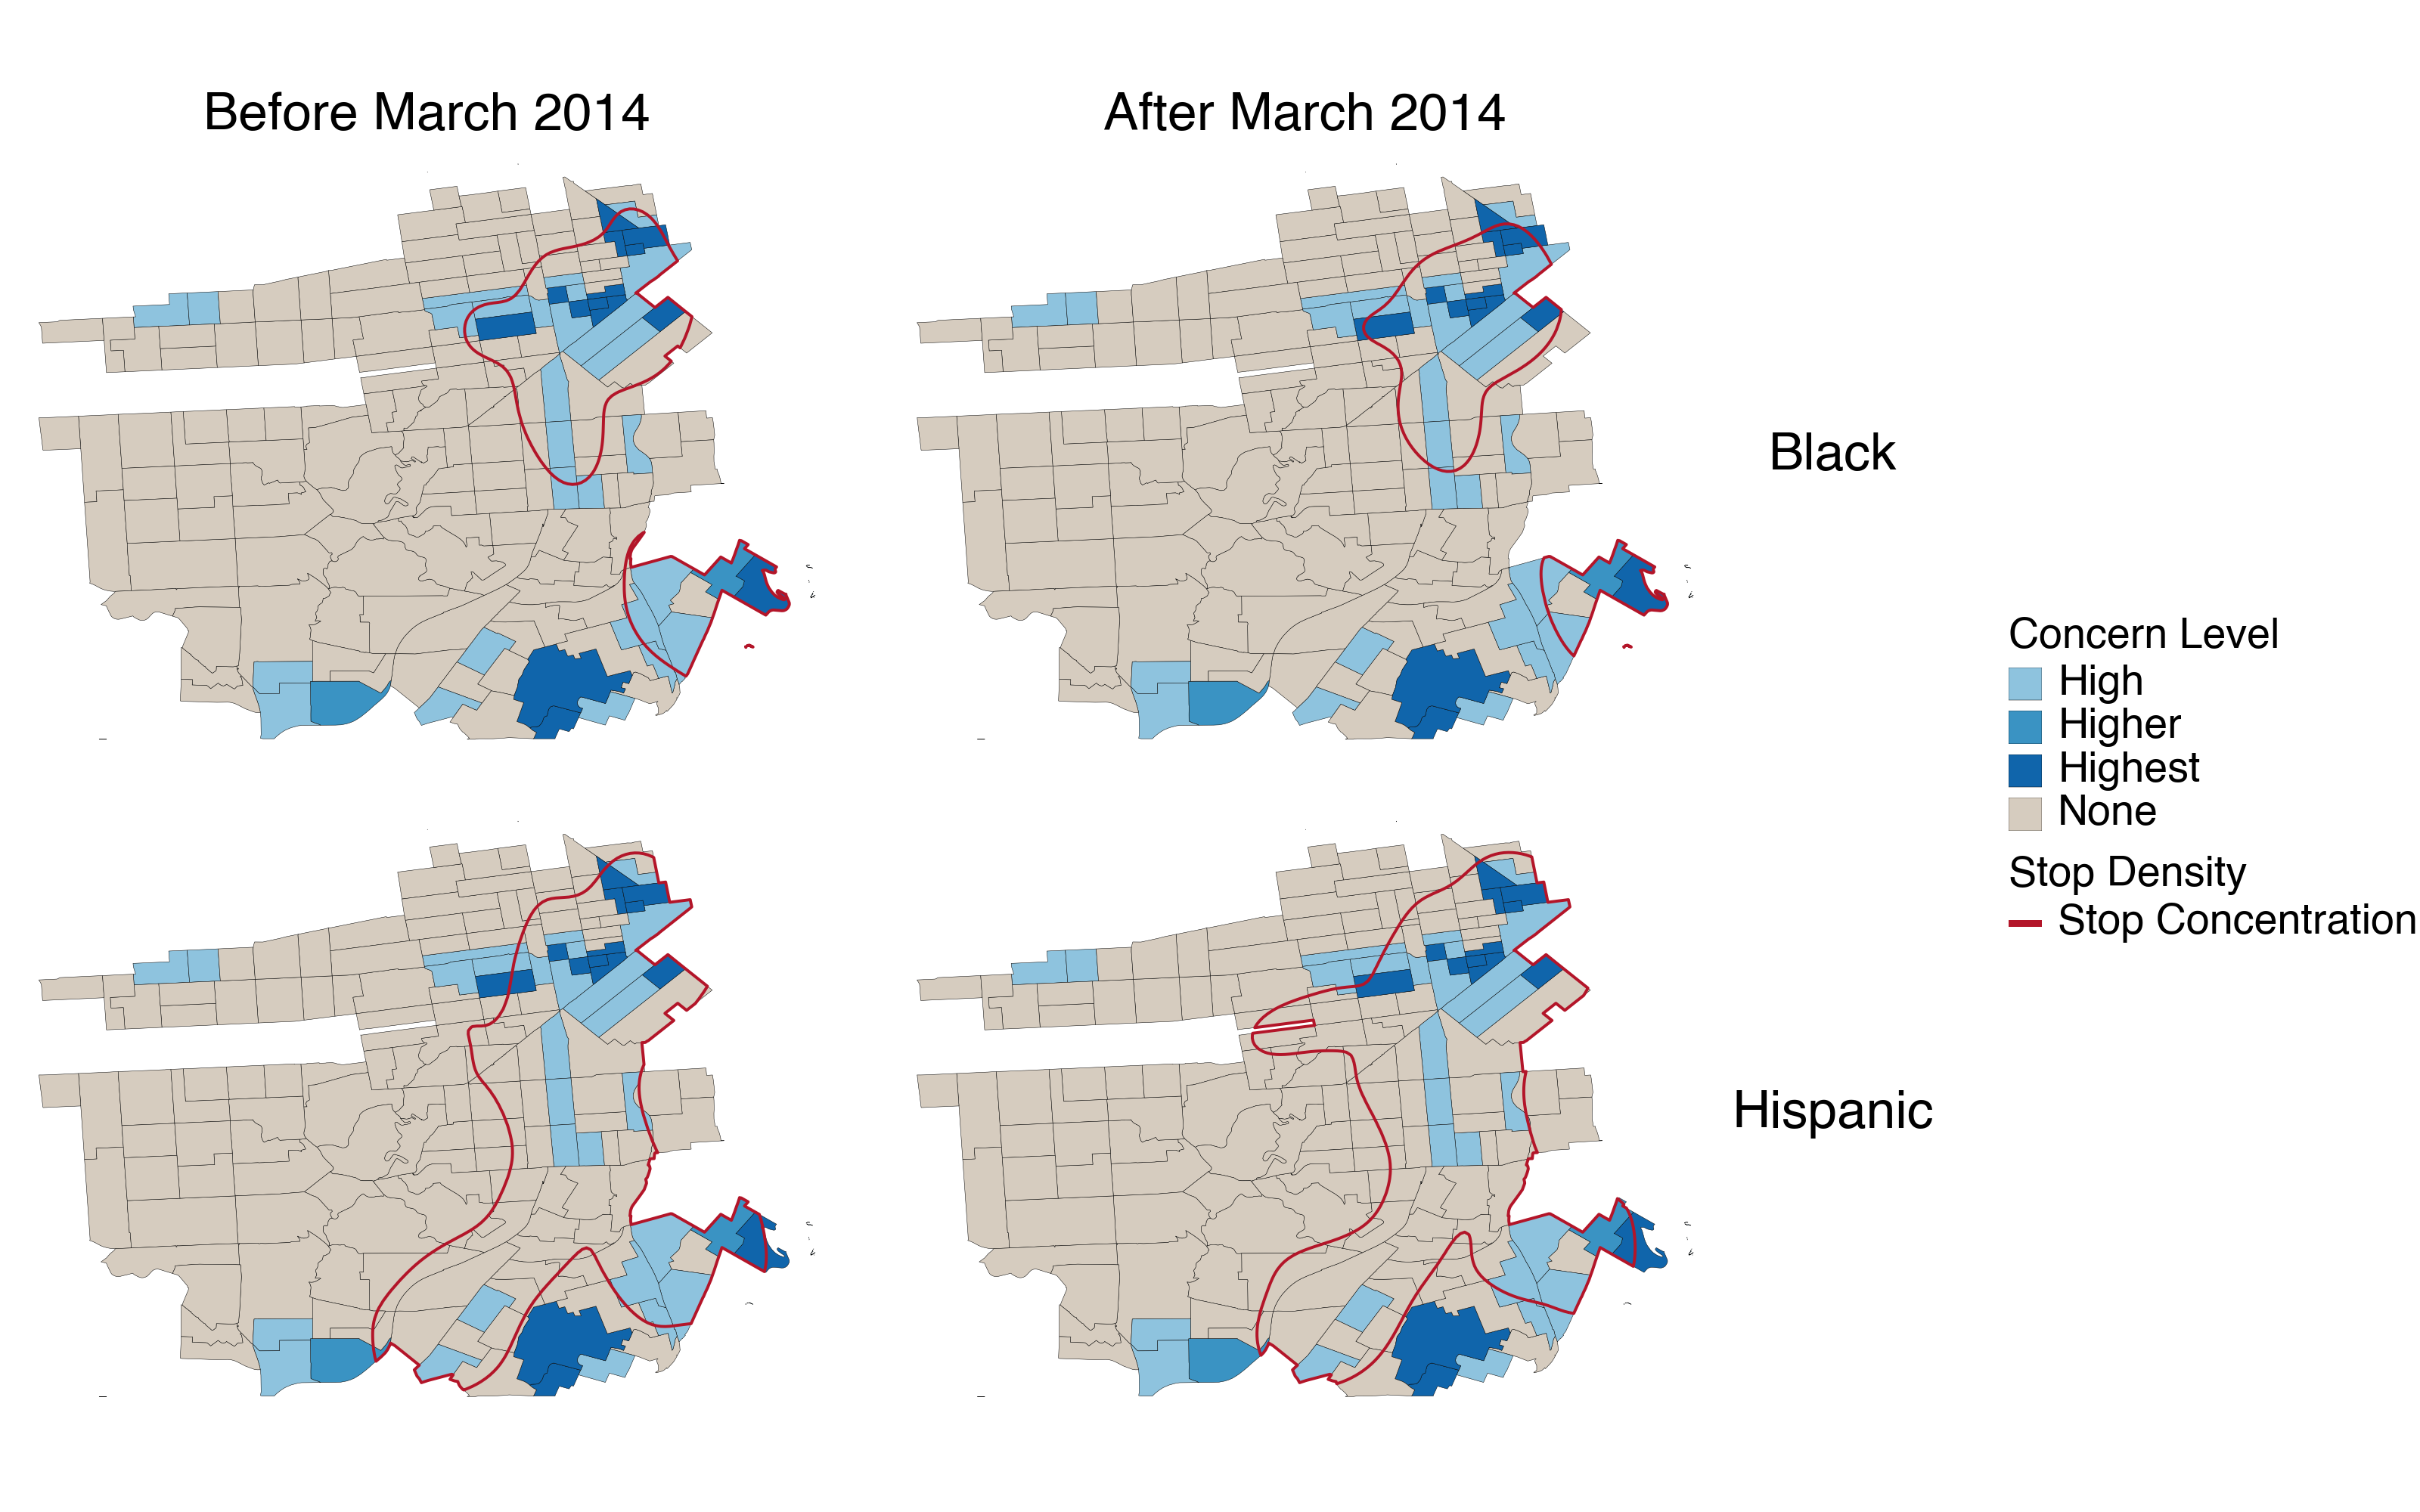

In [6]:
stops_period = prep_stops_period(stops_df, cutoff_date, races, race_map,
                                  race_col=race_col, date_col=date_col)

# build boundary from epc_gdf already filtered and reprojected to EPSG:4326
epc_reproj = epc_gdf[['epc_class', 'geometry']].copy()
epc_reproj['epc_class'] = epc_reproj['epc_class'].replace('NA', 'None').fillna('None')
epc_reproj = epc_reproj.to_crs("EPSG:4326")

# filter to county 
boundaries = county_gdf[county_gdf['county'].isin(['San Francisco'])]
epc_filtered = gpd.sjoin(epc_reproj, boundaries, predicate="within")

# get boundary for epcs
sf_boundary = unary_union(epc_filtered.geometry)
contour_df = get_clipped_contours(
    stops_period,
    x_col="lng",
    y_col="lat",
    group_cols=["subject_race", "period"],
    boundary=sf_boundary,
    levels=5
)

# add labels by policy period
before_label = f"Before {pd.Timestamp(cutoff_date).strftime('%B %Y')}"
after_label = f"After {pd.Timestamp(cutoff_date).strftime('%B %Y')}"
contour_df["period"] = pd.Categorical(
    contour_df["period"],
    categories=[before_label, after_label],
    ordered=True
)

epc_densities = plot_density_map(epc_polygon_df, contour_df)
save_plot(epc_densities, "density_map.png", output_dir=output_dir, width=16, height=10)
epc_densities



### Proportion of Stops Over Time by EPC Class
- Examine whether the share of stops within each community concern level shifted around the Vision Zero cutoff.

/Users/berkeleyho/Documents/College 22-26 Info/Spring '26/sds357-project-sp26-con-founders/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 5 in image.
/Users/berkeleyho/Documents/College 22-26 Info/Spring '26/sds357-project-sp26-con-founders/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../output/stops-time.png


plot saved to ../output/stops-time.png


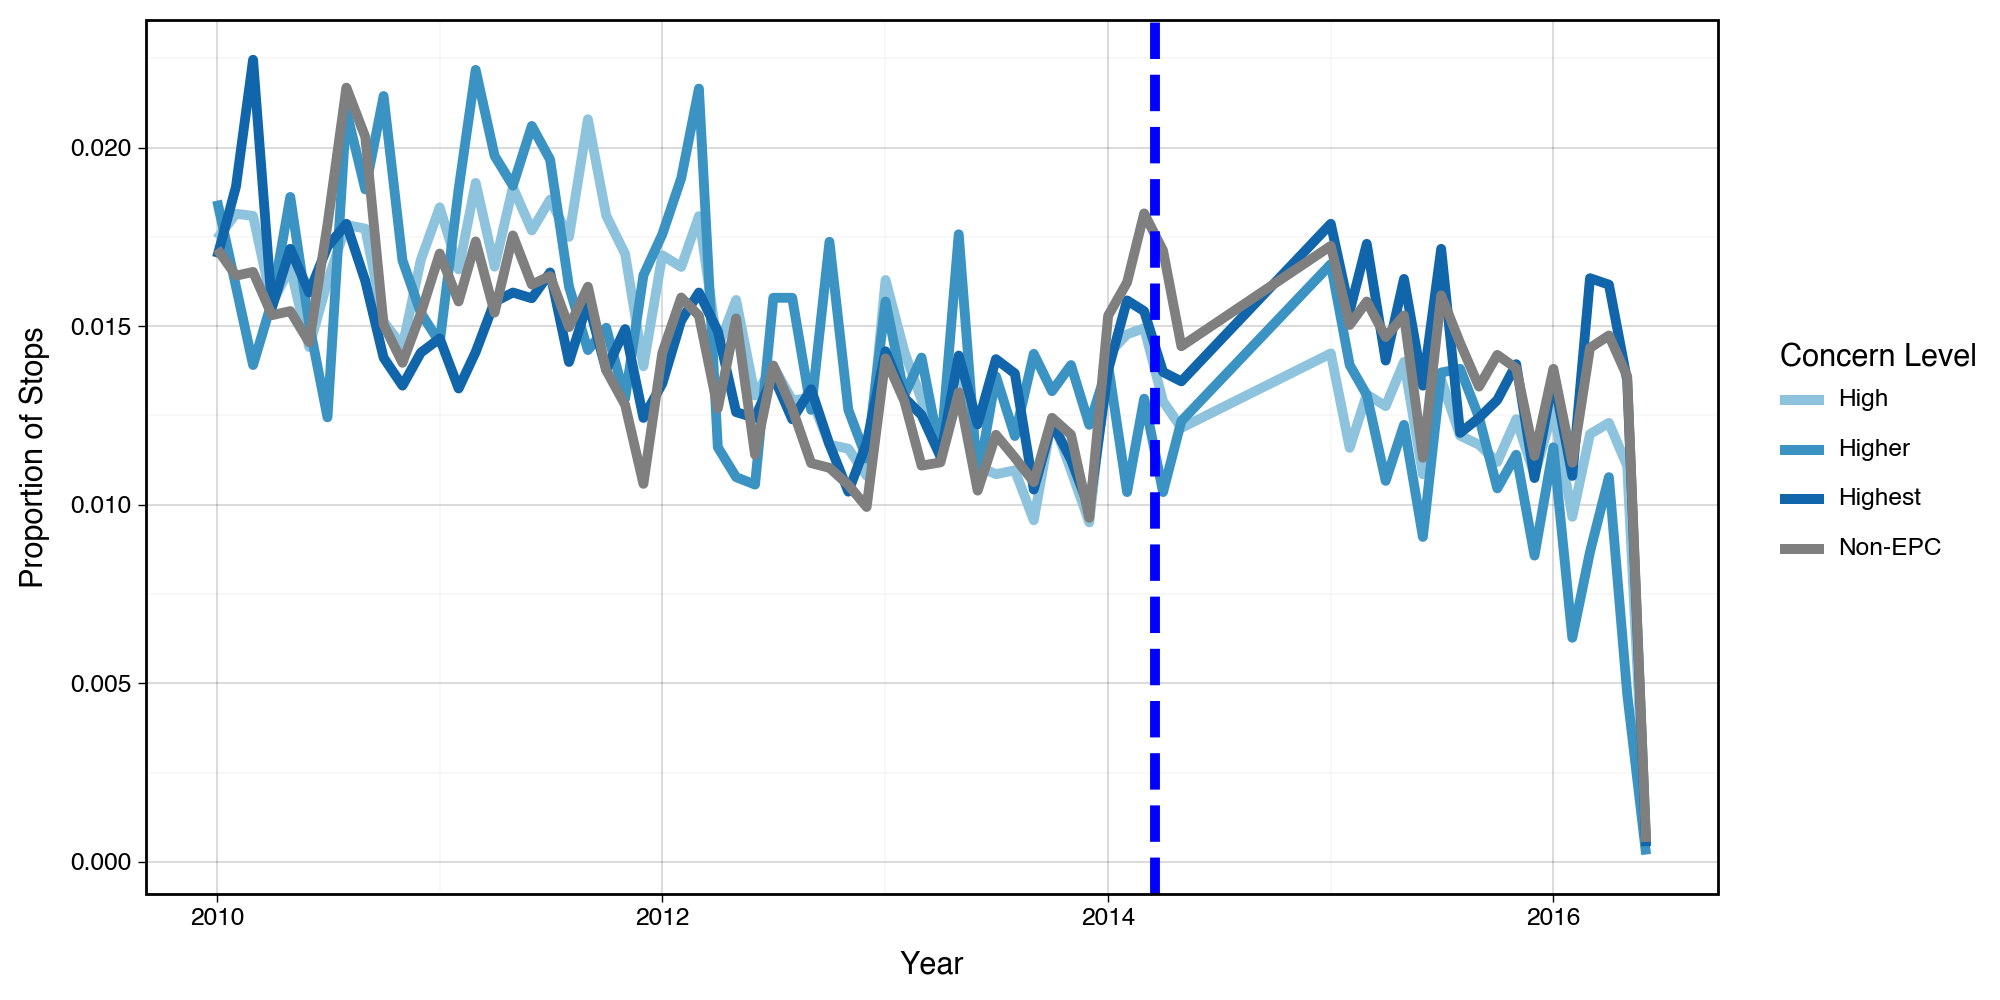

In [7]:
stop_prop_plot = plot_stops_proportion(stops_df, cutoff_date, date_col=date_col, epc_col=epc_col)
save_plot(stop_prop_plot, "stops-time.png", output_dir=output_dir, width=10, height=5)
stop_prop_plot

### Stops by Hour and Community of Concern
- Compare the time-of-day distribution of stops by race, inside and outside communities of concern.

epc_class
Non-EPC    321076
High       134225
Highest     49867
Higher       9560
Name: count, dtype: int64


/Users/berkeleyho/Documents/College 22-26 Info/Spring '26/sds357-project-sp26-con-founders/bias/src/bias_analysis_functions.py:478: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
/Users/berkeleyho/Documents/College 22-26 Info/Spring '26/sds357-project-sp26-con-founders/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12 x 6 in image.
/Users/berkeleyho/Documents/College 22-26 Info/Spring '26/sds357-project-sp26-con-founders/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../output/stops_by_hour.png


plot saved to ../output/stops_by_hour.png


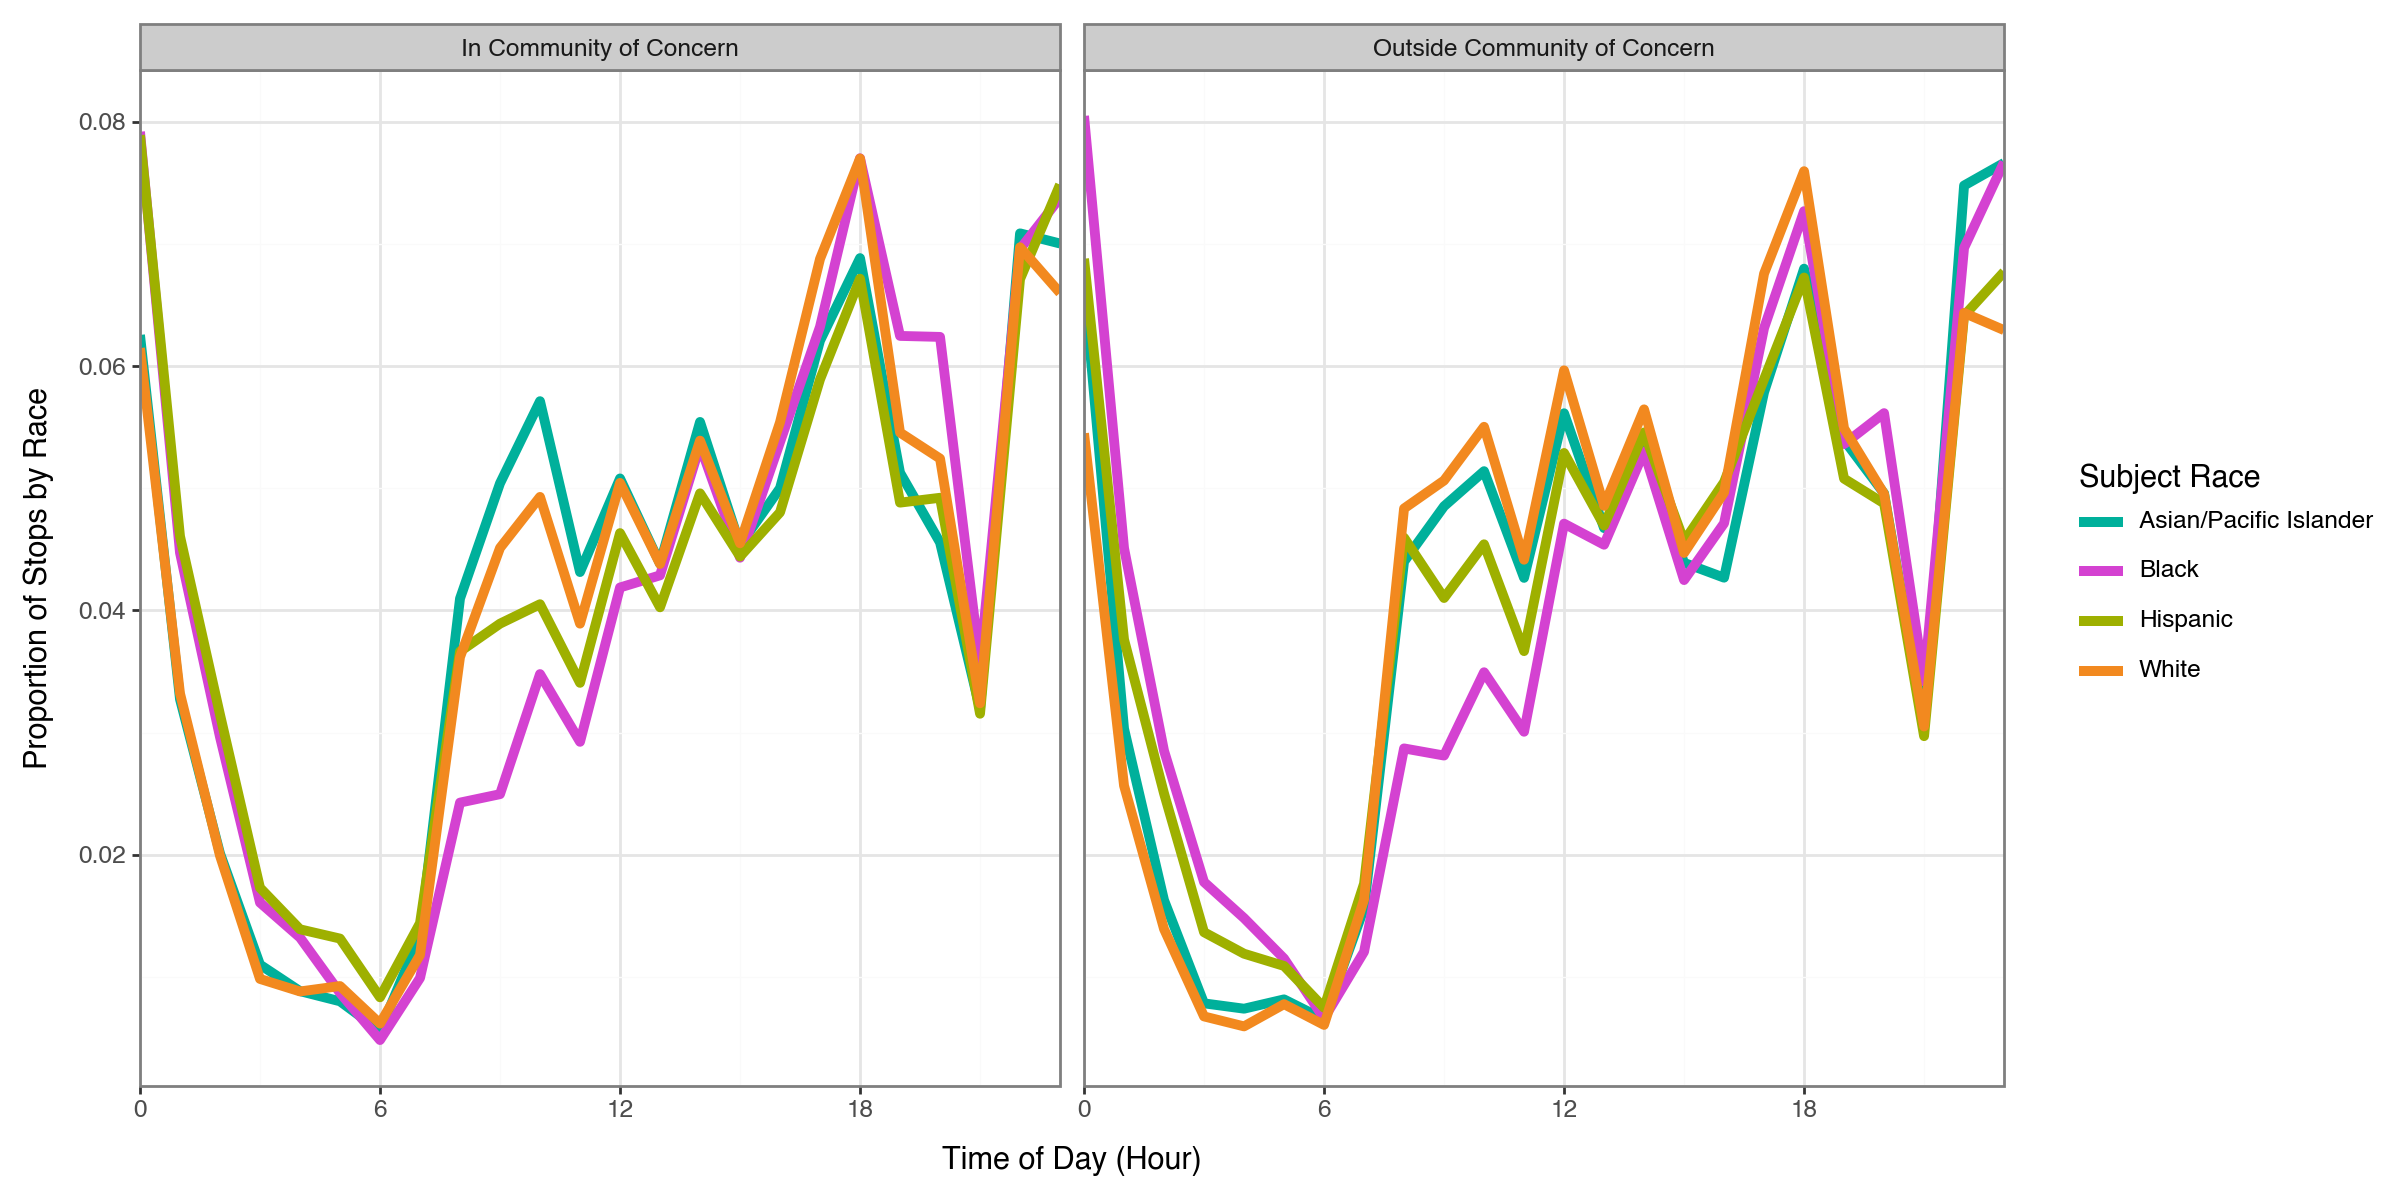

In [ ]:
print(stops_df[epc_col].value_counts(dropna=False))
hourly_stops_plot = plot_stops_by_hour(stops_df, race_col=race_col, epc_col=epc_col, time_col=time_col)
save_plot(hourly_stops_plot, "stops_by_hour.png", output_dir=output_dir, width=12, height=6)
hourly_stops_plot

### Stops Per Capita by Race
- Normalize stop counts by race group population to account for demographic composition of San Francisco.

stops per capita calculated
race labels remapped
plot saved to ../output/stops_per_capita.png


/Users/berkeleyho/Documents/College 22-26 Info/Spring '26/sds357-project-sp26-con-founders/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12 x 6 in image.
/Users/berkeleyho/Documents/College 22-26 Info/Spring '26/sds357-project-sp26-con-founders/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../output/stops_per_capita.png


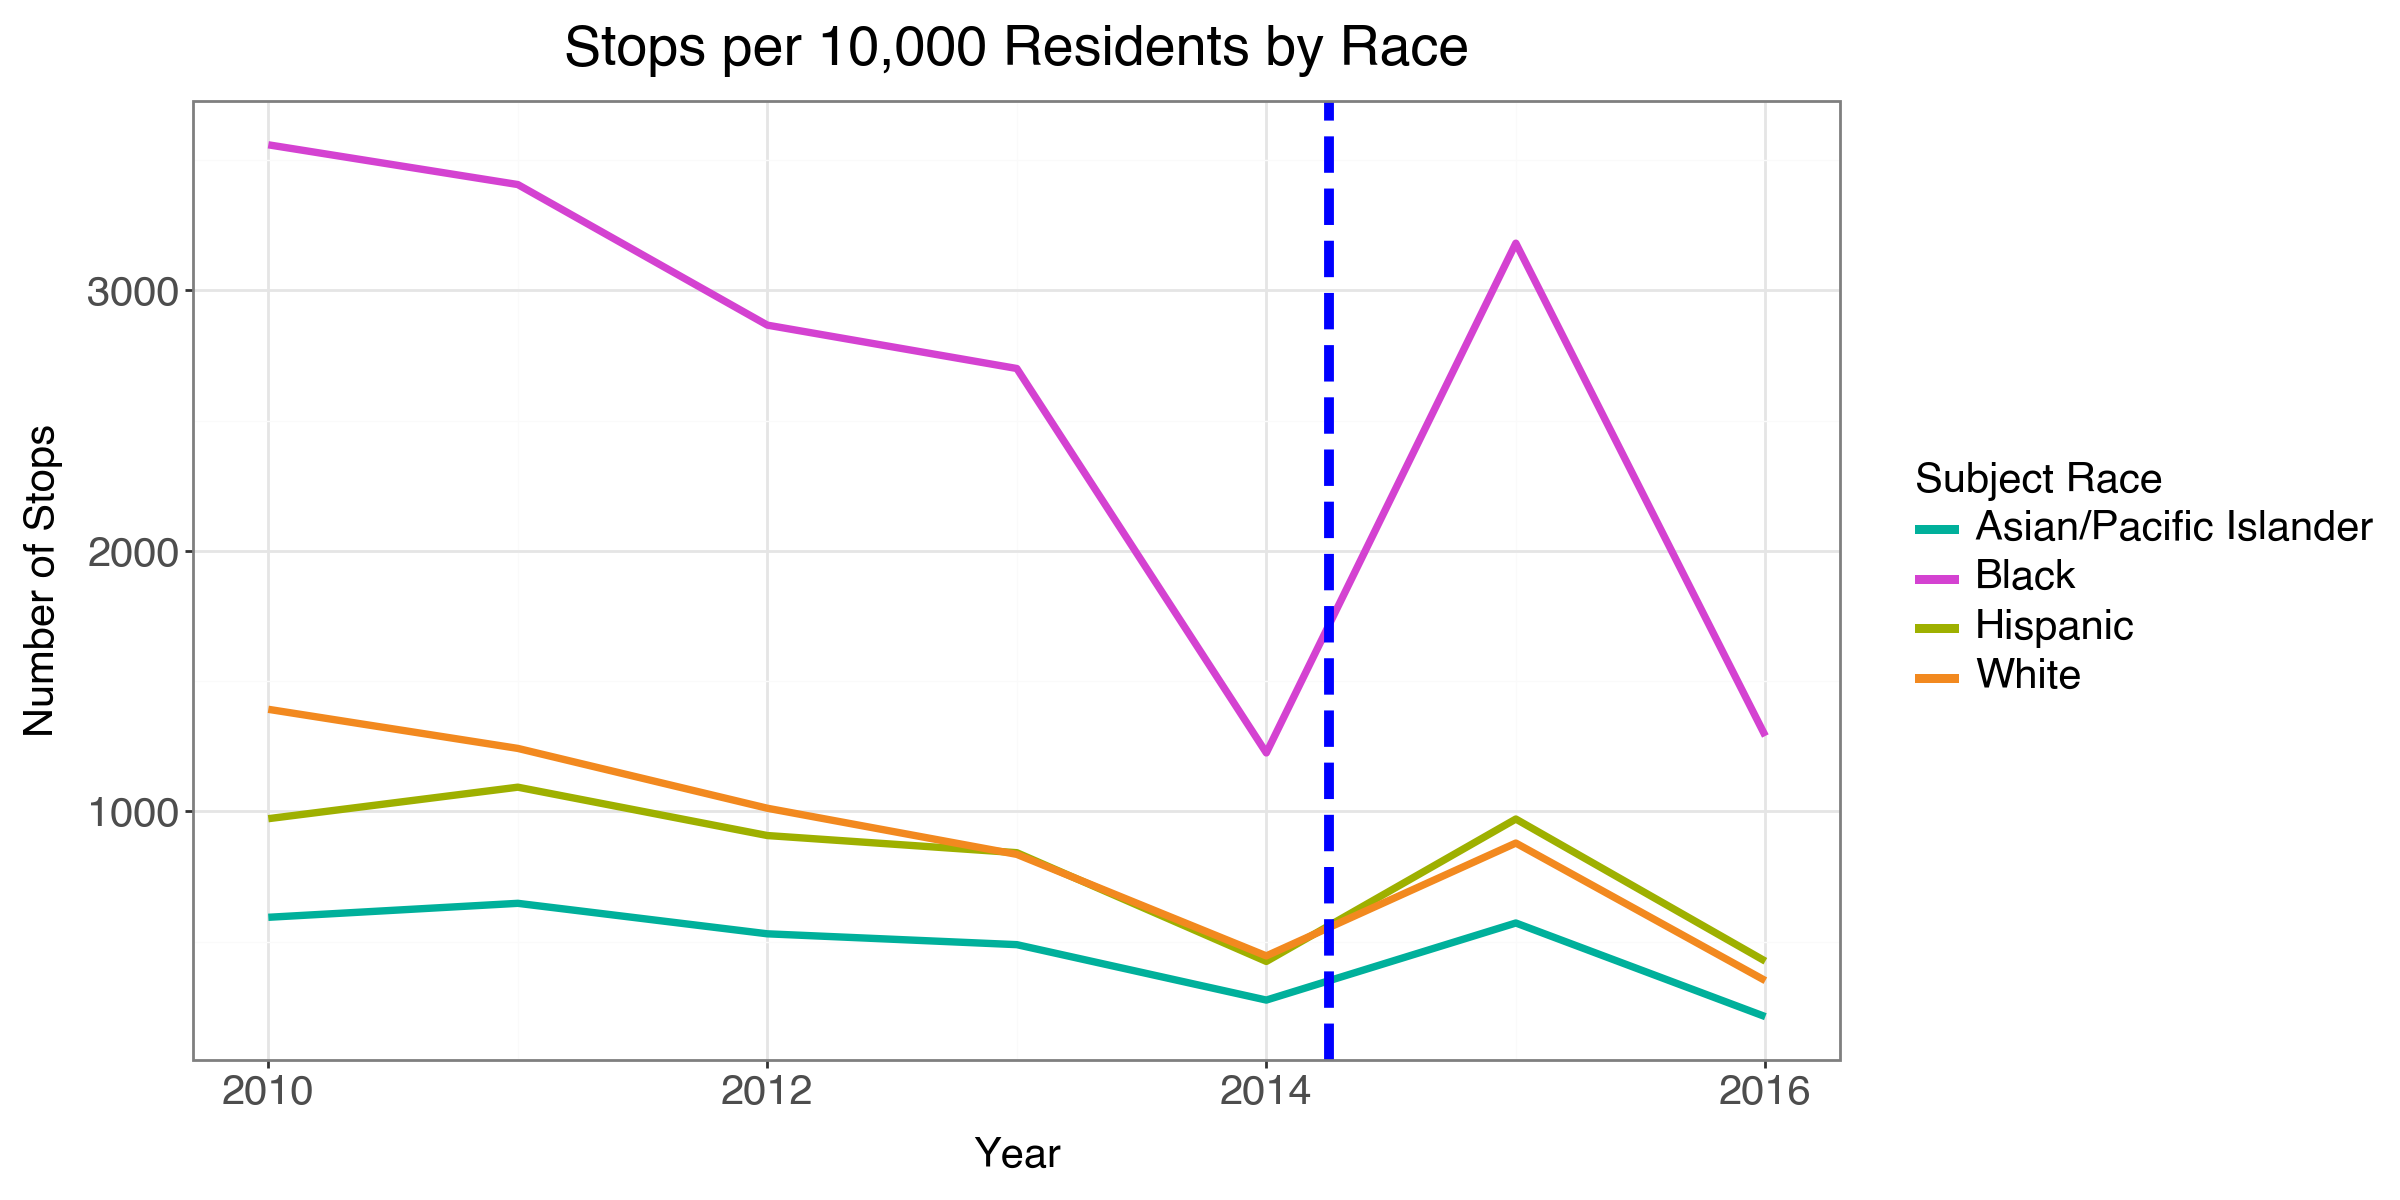

In [ ]:
stops_per_capita = get_stops_per_capita(stops_df, population, race_col=race_col)
stops_per_capita = remap_race_labels(stops_per_capita, race_map, race_col=race_col)

stops_race_plot = plot_stops_per_capita(stops_per_capita)
save_plot(stops_race_plot, "stops_per_capita.png", output_dir=output_dir)
stops_race_plot

### Outcome Rates by Race Over Time
- Compute and visualize the proportion of stops resulting in a search, warning, or citation, disaggregated by race.

search_conducted rate calculated
race labels remapped
plot saved to ../output/search_rate.png


/Users/berkeleyho/Documents/College 22-26 Info/Spring '26/sds357-project-sp26-con-founders/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12 x 6 in image.
/Users/berkeleyho/Documents/College 22-26 Info/Spring '26/sds357-project-sp26-con-founders/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../output/search_rate.png


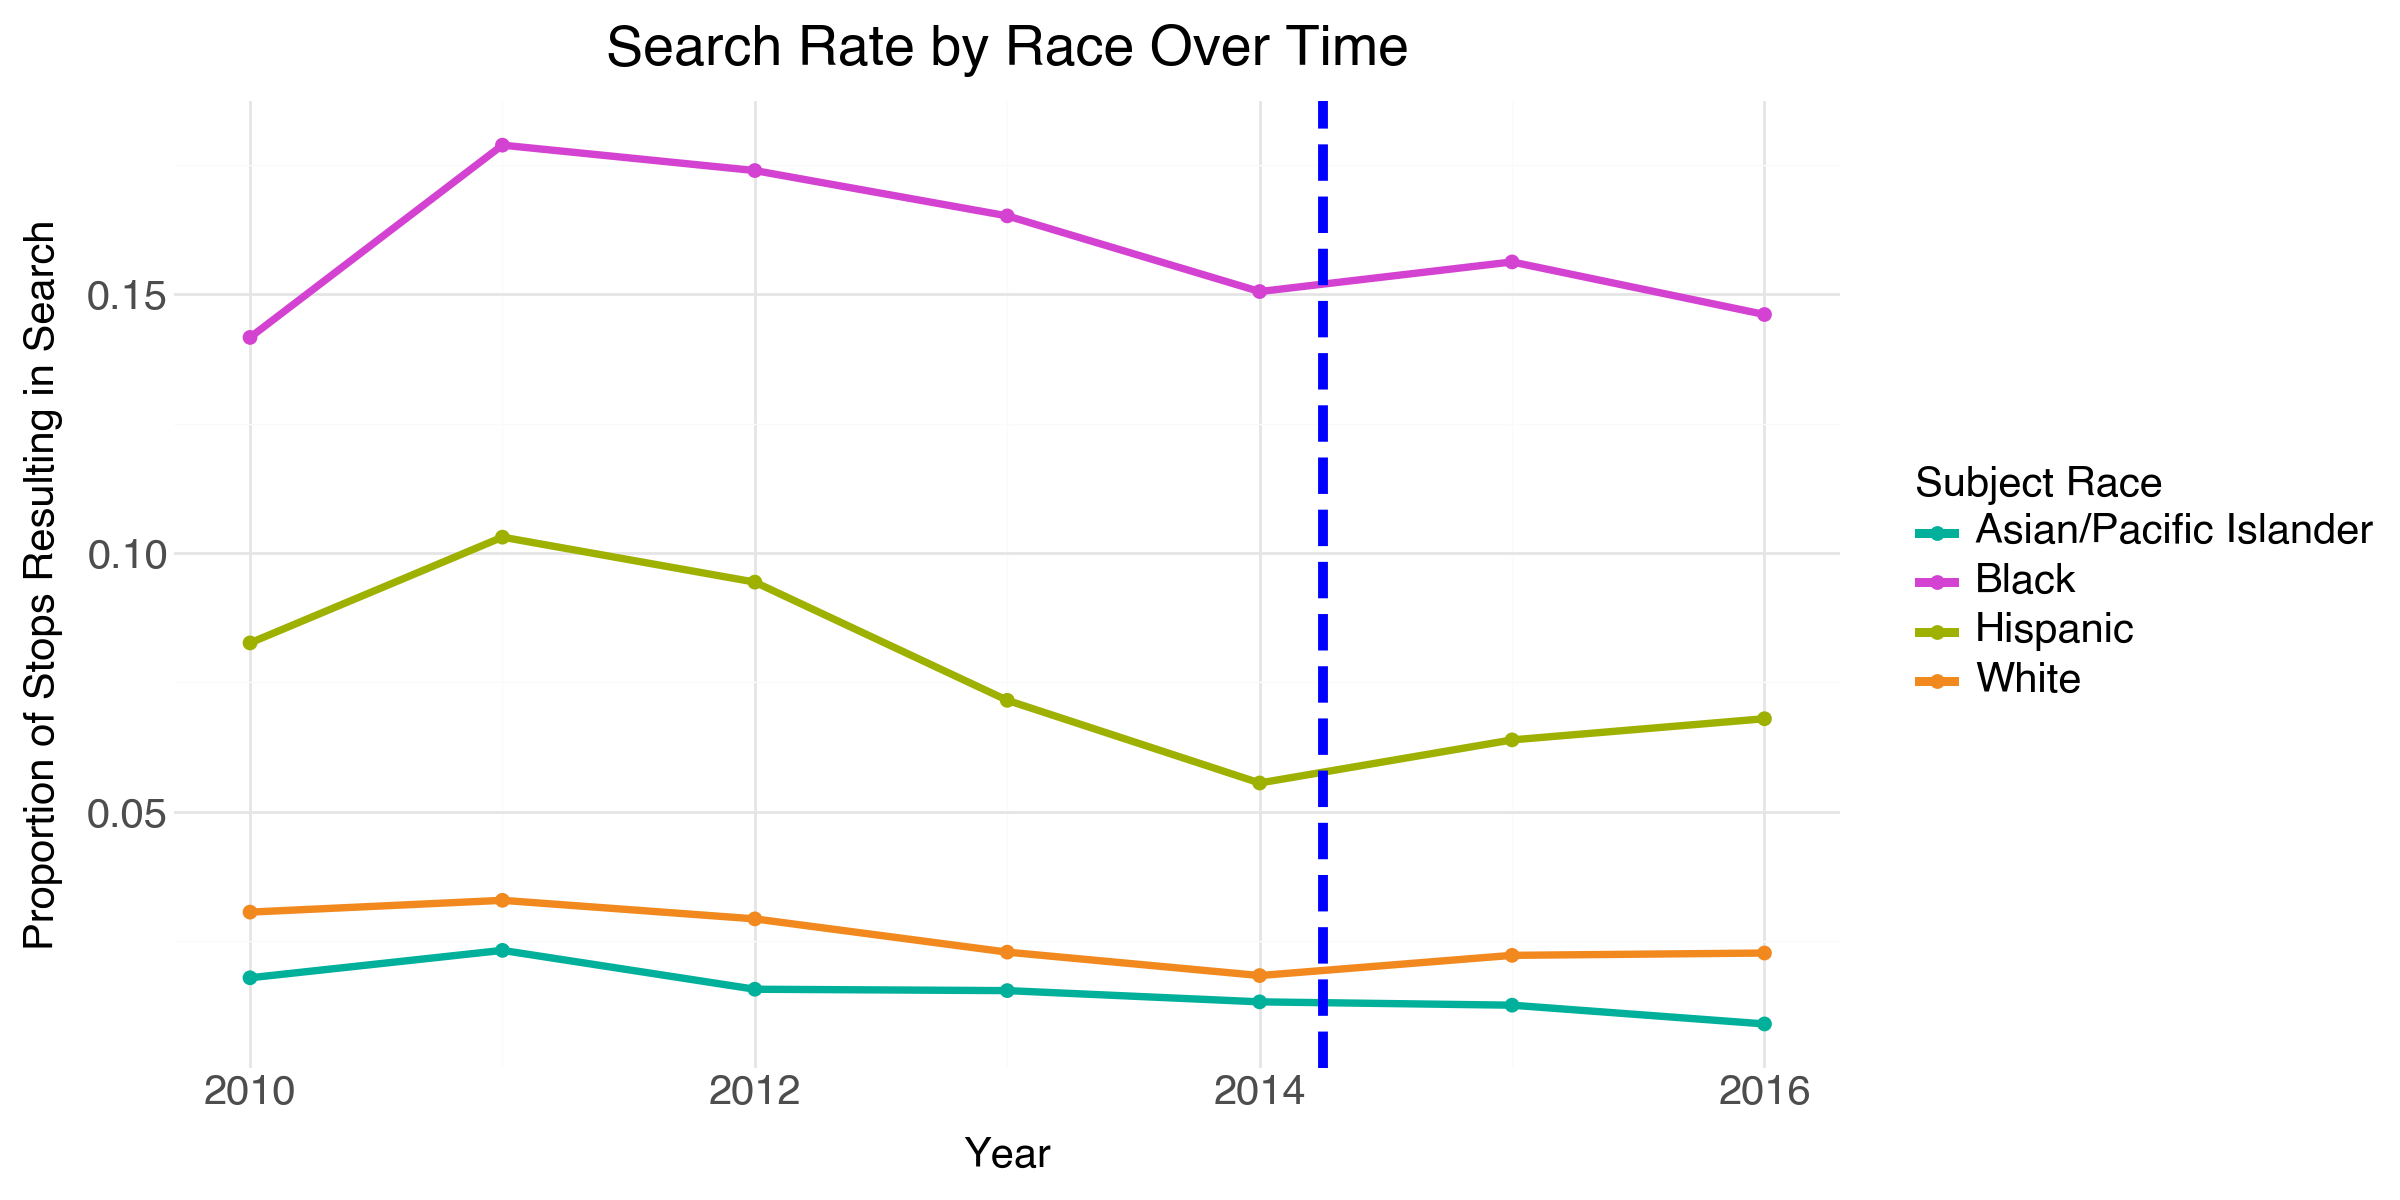

In [20]:
search_rate = get_outcome_rate(stops_df, outcome_col="search_conducted", race_col=race_col)
search_rate = remap_race_labels(search_rate, race_map, race_col=race_col)

search_plot = plot_outcome_rate(
    search_rate,
    title="Search Rate by Race Over Time",
    y_label="Proportion of Stops Resulting in Search"
)
save_plot(search_plot, "search_rate.png", output_dir=output_dir)
search_plot

warning_issued rate calculated
race labels remapped
plot saved to ../output/warning_rate.png


/Users/berkeleyho/Documents/College 22-26 Info/Spring '26/sds357-project-sp26-con-founders/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12 x 6 in image.
/Users/berkeleyho/Documents/College 22-26 Info/Spring '26/sds357-project-sp26-con-founders/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../output/warning_rate.png


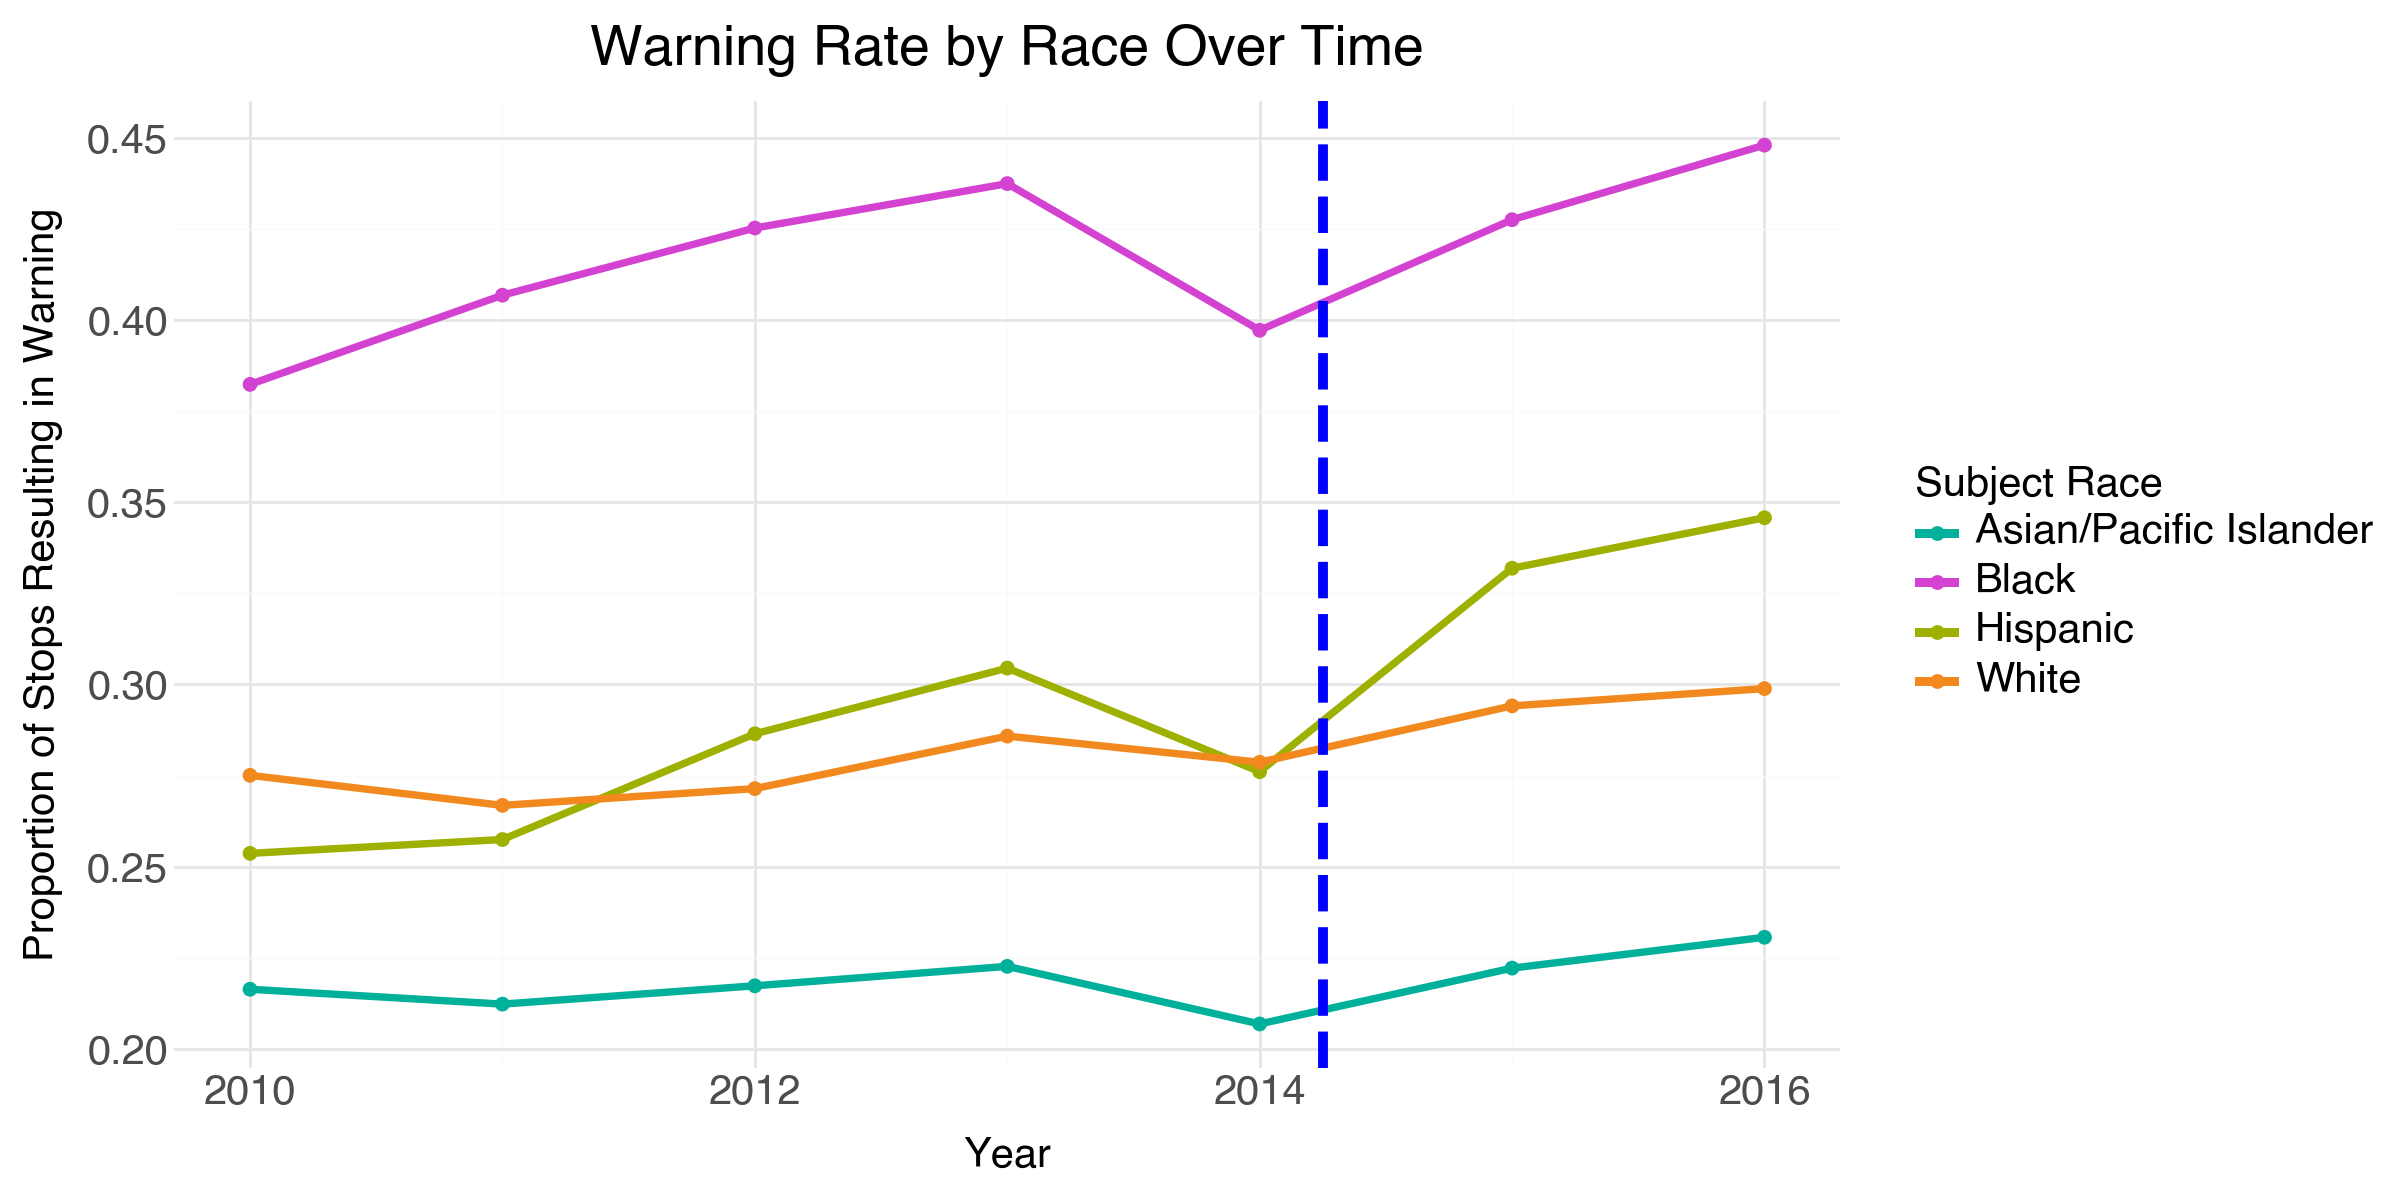

In [19]:
warning_rate = get_outcome_rate(stops_df, outcome_col="warning_issued", race_col=race_col)
warning_rate = remap_race_labels(warning_rate, race_map, race_col=race_col)

warning_plot = plot_outcome_rate(
    warning_rate,
    title="Warning Rate by Race Over Time",
    y_label="Proportion of Stops Resulting in Warning"
)
save_plot(warning_plot, "warning_rate.png", output_dir=output_dir)
warning_plot

citation_issued rate calculated
race labels remapped
plot saved to ../output/citation_rate.png


/Users/berkeleyho/Documents/College 22-26 Info/Spring '26/sds357-project-sp26-con-founders/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12 x 6 in image.
/Users/berkeleyho/Documents/College 22-26 Info/Spring '26/sds357-project-sp26-con-founders/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../output/citation_rate.png


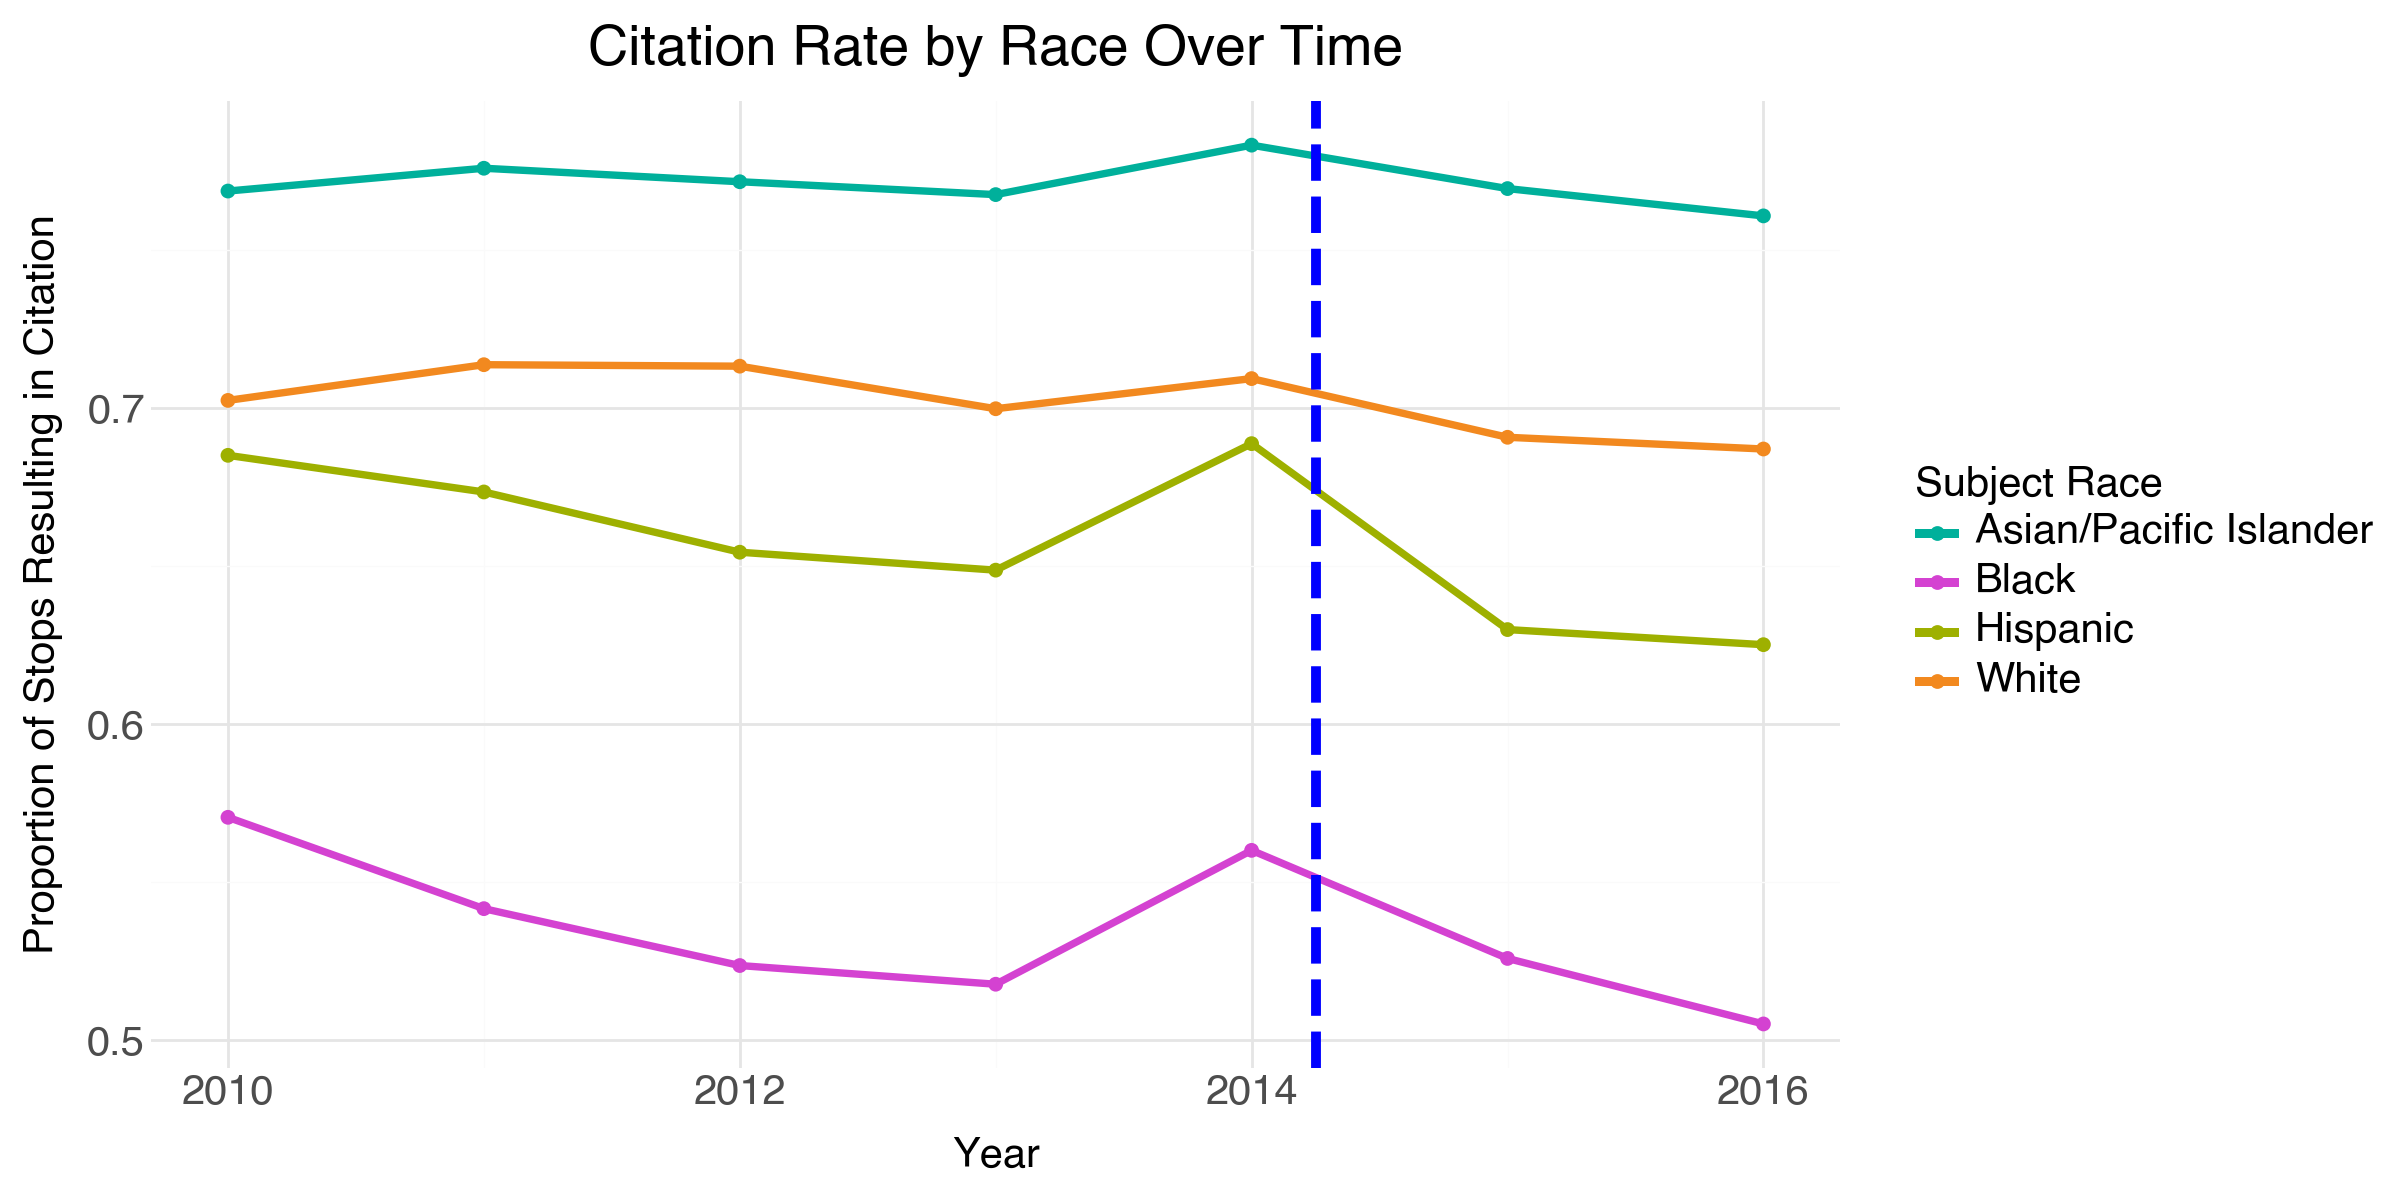

In [17]:
citation_rate = get_outcome_rate(stops_df, outcome_col="citation_issued", race_col=race_col)
citation_rate = remap_race_labels(citation_rate, race_map, race_col=race_col)

citation_plot = plot_outcome_rate(
    citation_rate,
    title="Citation Rate by Race Over Time",
    y_label="Proportion of Stops Resulting in Citation"
)
save_plot(citation_plot, "citation_rate.png", output_dir=output_dir)
citation_plot